
Kr_R1s(r) =
+269.1356 * exp(-32.8351 r)
+156.7319 * exp(-40.9447 r)
-84.5768 * r * exp(-27.4580 r)
+10.7170 * r * exp(-16.0666 r)
-21.6137 * r^2 * exp(-14.2962 r)
+1.8277 * r^2 * exp(-9.1094 r)
-0.2423 * r^2 * exp(-6.3718 r)
+0.0126 * r^3 * exp(-3.8455 r)
-0.0014 * r^3 * exp(-2.5790 r)
+0.0001 * r^3 * exp(-1.7719 r)

Kr_R2s(r) =
+143.5181 * exp(-32.8351 r)
-9.5524 * exp(-40.9447 r)
+783.4989 * r * exp(-27.4580 r)
-1280.3008 * r * exp(-16.0666 r)
-694.6658 * r^2 * exp(-14.2962 r)
-18.4692 * r^2 * exp(-9.1094 r)
+1.1041 * r^2 * exp(-6.3718 r)
-0.0590 * r^3 * exp(-3.8455 r)
+0.0042 * r^3 * exp(-2.5790 r)
-0.0005 * r^3 * exp(-1.7719 r)

Kr_R3s(r) =
-54.7257 * exp(-32.8351 r)
+0.9484 * exp(-40.9447 r)
-412.2550 * r * exp(-27.4580 r)
+591.7389 * r * exp(-16.0666 r)
+1185.5387 * r^2 * exp(-14.2962 r)
-466.5793 * r^2 * exp(-9.1094 r)
-208.1326 * r^2 * exp(-6.3718 r)
-0.5813 * r^3 * exp(-3.8455 r)
-0.0175 * r^3 * exp(-2.5790 r)
-0.0013 * r^3 * exp(-1.7719 r)

Kr_R4s(r) =
-16.3654 * exp(-32.835

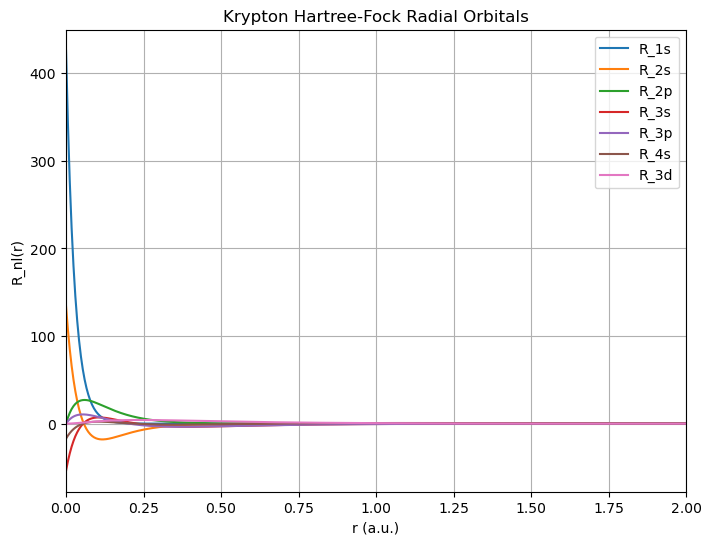

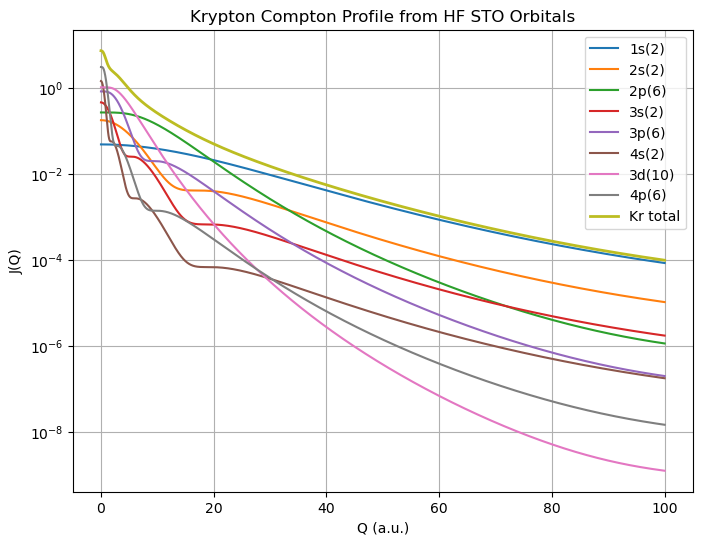

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid,simpson

# =====================================================
# Krypton Hartree-Fock STO data
# Kr: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(6)
# Ground term: 1S
# Format: (n_j, Z_j, C_j)
# =====================================================

krypton_1s = [
    (1, 32.83510,  0.71521),
    (1, 40.94470,  0.29911),
    (2, 27.45800, -0.01854),
    (2, 16.06660,  0.00897),
    (3, 14.29620, -0.00464),
    (3,  9.10937,  0.00190),
    (3,  6.37181, -0.00088),
    (4,  3.84546,  0.00026),
    (4,  2.57902, -0.00018),
    (4,  1.77192,  0.00006),
]

krypton_2s = [
    (1, 32.83510,  0.38139),
    (1, 40.94470, -0.01823),
    (2, 27.45800,  0.17175),
    (2, 16.06660, -1.07160),
    (3, 14.29620, -0.14913),
    (3,  9.10937, -0.01920),
    (3,  6.37181,  0.00401),
    (4,  3.84546, -0.00122),
    (4,  2.57902,  0.00052),
    (4,  1.77192, -0.00031),
]

krypton_3s = [
    (1, 32.83510, -0.14543),
    (1, 40.94470,  0.00181),
    (2, 27.45800, -0.09037),
    (2, 16.06660,  0.49528),
    (3, 14.29620,  0.25451),
    (3,  9.10937, -0.48504),
    (3,  6.37181, -0.75593),
    (4,  3.84546, -0.01203),
    (4,  2.57902, -0.00218),
    (4,  1.77192, -0.00085),
]

krypton_4s = [
    (1, 32.83510, -0.04349),
    (1, 40.94470, -0.00148),
    (2, 27.45800, -0.03219),
    (2, 16.06660,  0.16451),
    (3, 14.29620,  0.08852),
    (3,  9.10937, -0.16671),
    (3,  6.37181, -0.33291),
    (4,  3.84546,  0.46913),
    (4,  2.57902,  0.55106),
    (4,  1.77192,  0.13572),
]

krypton_2p = [
    (2, 17.03660,  0.72322),
    (2, 26.04380,  0.06774),
    (3, 15.51000,  0.22056),
    (3,  9.49403,  0.04478),
    (3,  6.57275, -0.01672),
    (4,  5.38507,  0.00609),
    (4,  3.15603, -0.00195),
    (4,  2.02966,  0.00111),
    (4,  1.42733, -0.00040),
]

krypton_3p = [
    (2, 17.03660,  0.30185),
    (2, 26.04380,  0.02508),
    (3, 15.51000,  0.15903),
    (3,  9.49403, -0.28475),
    (3,  6.57275, -0.76440),
    (4,  5.38507, -0.10670),
    (4,  3.15603, -0.00562),
    (4,  2.02966,  0.00137),
    (4,  1.42733, -0.00053),
]

krypton_4p = [
    (2, 17.03660,  0.08488),
    (2, 26.04380,  0.00571),
    (3, 15.51000,  0.04169),
    (3,  9.49403, -0.07425),
    (3,  6.57275, -0.26866),
    (4,  5.38507,  0.01341),
    (4,  3.15603,  0.51241),
    (4,  2.02966,  0.42557),
    (4,  1.42733,  0.18141),
]

krypton_3d = [
    (3,  5.30650, 0.50854),
    (3,  3.36240, 0.11070),
    (3,  7.54963, 0.24778),
    (3, 10.35430, 0.20584),
    (3, 17.11420, 0.02863),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2

        # Simpson rule for chi(p)
        val = np.sqrt(2/np.pi) * simpson(integrand, x=r_grid)

        chi.append(val)

    return np.array(chi)
# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, krypton_1s)
R2s = R_nl(r, krypton_2s)
R3s = R_nl(r, krypton_3s)
R4s = R_nl(r, krypton_4s)
R2p = R_nl(r, krypton_2p)
R3p = R_nl(r, krypton_3p)
R3d = R_nl(r, krypton_3d)
R4p = R_nl(r, krypton_4p)

print_R_formula(krypton_1s, "Kr_R1s")
print_R_formula(krypton_2s, "Kr_R2s")
print_R_formula(krypton_3s, "Kr_R3s")
print_R_formula(krypton_4s, "Kr_R4s")
print_R_formula(krypton_2p, "Kr_R2p")
print_R_formula(krypton_3p, "Kr_R3p")
print_R_formula(krypton_3d, "Kr_R3d")
print_R_formula(krypton_4p, "Kr_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", simpson(I_1s, x=p))
print("Norm 2s =", simpson(I_2s, x=p))
print("Norm 2p =", simpson(I_2p, x=p))
print("Norm 3s =", simpson(I_3s, x=p))
print("Norm 3p =", simpson(I_3p, x=p))
print("Norm 3d =", simpson(I_3d, x=p))
print("Norm 4s =", simpson(I_4s, x=p))
print("Norm 4p =", simpson(I_4p, x=p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(6)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 6*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(2)": 6*J_4p,
    "J_total_Kr": J_total
    })
print(table)
table.to_csv("Krypton_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Krypton Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 6*J_4p, label="4p(6)")
plt.plot(Q, J_total, label="Kr total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Krypton Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()